# 5. Modelos base de regresión

Tras fijar los benchmarks econométricos del Capítulo 4, este capítulo
entrena los **siete modelos base de regresión** exigidos por la
rúbrica:

1. Ridge {cite}`hoerl1970ridge`
2. Lasso {cite}`tibshirani1996regression`
3. K-Nearest Neighbors Regressor
4. Decision Tree Regressor
5. Random Forest Regressor {cite}`breiman2001random`
6. Support Vector Regression
7. XGBoost {cite}`chen2016xgboost`

## 5.1 Filosofía del capítulo

Tres reglas no negociables que dictan toda la implementación:

**Pipeline o no existe.** Cada modelo se entrena dentro de un
`sklearn.pipeline.Pipeline` que encapsula imputación de valores
faltantes (mediana, robusta a outliers) y escalado estándar
(necesario para Ridge, Lasso, KNN, SVR, irrelevante para árboles
pero inocuo). El imputador y el scaler **se ajustan solo con train**
y se aplican a val y test. Esto descarta el leakage de medias y
desviaciones.

**Hiperparámetros baseline, no optimizados.** En este capítulo cada
modelo se entrena con una configuración por defecto razonable —
defaults de scikit-learn ajustados para evitar sobreajuste obvio
(por ejemplo, `max_depth=8` en el Decision Tree). La optimización
sistemática de hiperparámetros se hace en el Capítulo 8 con
Grid/Random Search, Optuna y DEAP.

**Validation + test ambas.** Reportamos las dos métricas para que
quede transparente si el modelo overfittea (gap grande val→test) o
generaliza (gap pequeño). El test se usa solo aquí como "métrica
final"; las decisiones de arquitectura del modelo original (NB 13)
se tomarán solo con validation.

## 5.2 Métricas y criterios

Tres métricas:

- **RMSE** — métrica principal de la rúbrica. Penaliza errores grandes.
- **MAE** — más interpretable en la escala de la volatilidad.
- **R²** — métrica complementaria. Compara el modelo contra predecir
  la media histórica. **Un R² negativo en test significa que el modelo
  hace peor que la línea horizontal** — algo que ya nos pasó en
  el proyecto anterior con horizonte 7 días y que aquí esperamos
  evitar gracias al horizonte 1.

**Línea a batir:** Naive del Capítulo 4 con RMSE 0.00425 / MAE 0.00232
en test. Si un modelo no supera a Naive, debe declararse honestamente
y discutirse por qué.

## 5.3 XGBoost con `tree_method="hist"` + early stopping

XGBoost se evalúa con dos optimizaciones computacionales habilitadas
desde el inicio:

- `tree_method="hist"` — discretiza features en histogramas, reduce
  complejidad por nodo de $O(n_{\text{features}} \cdot n_{\text{samples}})$
  a $O(n_{\text{bins}})$ y acelera significativamente sin pérdida de
  precisión {cite}`chen2016xgboost`.
- `early_stopping_rounds=20` con `eval_set=val` — detiene la
  construcción de árboles cuando el RMSE en validation deja de
  mejorar por 20 iteraciones consecutivas. Funciona como
  regularización implícita y evita sobreajuste.

Estas técnicas se vuelven a discutir aisladamente en el Capítulo 9
(optimización computacional) comparando "estándar vs. hist+early".


## 5.4 Setup y carga de datos

In [1]:
import sys
from pathlib import Path
import time
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, PREDICTIONS_DIR, MODELS_DIR,
    FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json, save_model
from src import benchmarks  # para comparar con Naive del NB 04

ensure_dirs()
set_style()
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(RANDOM_STATE)


In [2]:
# Cargar splits y reconstruir full_df
tr = pd.read_parquet(PROJECT_ROOT / "data/processed/train.parquet")
va = pd.read_parquet(PROJECT_ROOT / "data/processed/val.parquet")
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")

# Cargar lista de features causales
with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]
print(f"Número de features causales: {len(feature_cols)}")

# Filtrar filas sin target (las últimas de cada split por el shift(-1))
def split_xy(df, cols):
    mask = df["target_vol"].notna()
    return df.loc[mask, cols].to_numpy(), df.loc[mask, "target_vol"].to_numpy()

X_train, y_train = split_xy(tr, feature_cols)
X_val,   y_val   = split_xy(va, feature_cols)
X_test,  y_test  = split_xy(te, feature_cols)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")


Número de features causales: 31
X_train: (4873, 31)
X_val:   (1044, 31)
X_test:  (1045, 31)


## 5.5 Función helper para evaluación uniforme

Esta función entrena un pipeline, predice sobre val y test, calcula
las tres métricas en ambos conjuntos y persiste el modelo y las
predicciones a disco. Esto garantiza consistencia en cómo se evalúa
cada modelo.

In [3]:
def evaluate_model(name: str, pipeline, X_train, y_train, X_val, y_val, X_test, y_test):
    # Entrena `pipeline` con (X_train, y_train) y evalúa en val y test.
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    fit_s = time.time() - t0

    pred_val  = np.maximum(pipeline.predict(X_val), 0.0)
    pred_test = np.maximum(pipeline.predict(X_test), 0.0)

    rmse_val  = float(np.sqrt(mean_squared_error(y_val,  pred_val)))
    mae_val   = float(mean_absolute_error(y_val,  pred_val))
    r2_val    = float(r2_score(y_val,  pred_val))
    rmse_test = float(np.sqrt(mean_squared_error(y_test, pred_test)))
    mae_test  = float(mean_absolute_error(y_test, pred_test))
    r2_test   = float(r2_score(y_test, pred_test))

    save_model(pipeline, MODELS_DIR / f"05_{name}.joblib")

    print(f"{name:>10s} | "
          f"val:  RMSE={rmse_val:.5f} MAE={mae_val:.5f} R²={r2_val:+.4f}  |  "
          f"test: RMSE={rmse_test:.5f} MAE={mae_test:.5f} R²={r2_test:+.4f}  |  "
          f"fit={fit_s:.2f}s")

    return {
        "name": name,
        "rmse_val": rmse_val, "mae_val": mae_val, "r2_val": r2_val,
        "rmse_test": rmse_test, "mae_test": mae_test, "r2_test": r2_test,
        "fit_s": fit_s,
        "pred_val": pred_val,
        "pred_test": pred_test,
    }


## 5.6 Ridge y Lasso

Regresión lineal regularizada. Mientras Ridge {cite}`hoerl1970ridge`
penaliza el cuadrado de los coeficientes ($L_2$), Lasso
{cite}`tibshirani1996regression` penaliza el valor absoluto ($L_1$)
e induce esparsidad — algunos coeficientes se vuelven exactamente
cero.

En nuestro problema:

- **Ridge** sirve como benchmark lineal "todo incluido": usa
  todos los features con coeficientes pequeños. Es resistente a la
  multicolinealidad (por ejemplo, entre `vol_d`, `vol_w`, `vol_m`
  del modelo HAR-RV).
- **Lasso** revela cuáles features merecen sobrevivir. Si después de
  Lasso, las features dominantes son las componentes HAR, eso es
  evidencia adicional de que Corsi (2009) capturó la dinámica
  esencial.

Hiperparámetros baseline:

- Ridge: $\alpha = 1.0$ (default scikit-learn).
- Lasso: $\alpha = 10^{-3}$, `max_iter=20000`. El valor pequeño de
  $\alpha$ refleja la escala de las features escaladas (post-standard);
  el `max_iter` elevado asegura convergencia.


In [4]:
results = {}

results["ridge"] = evaluate_model(
    "ridge",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)

results["lasso"] = evaluate_model(
    "lasso",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   Lasso(alpha=1e-3, random_state=RANDOM_STATE, max_iter=20000)),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


     ridge | val:  RMSE=0.00358 MAE=0.00264 R²=+0.6774  |  test: RMSE=0.00384 MAE=0.00257 R²=+0.7155  |  fit=0.04s
     lasso | val:  RMSE=0.00388 MAE=0.00292 R²=+0.6199  |  test: RMSE=0.00426 MAE=0.00301 R²=+0.6492  |  fit=0.01s


## 5.7 K-Nearest Neighbors Regressor

KNN no asume forma funcional: predice promediando los $k$ vecinos
más cercanos en el espacio de features. Captura interacciones no
lineales sin modelarlas explícitamente, a costa de pérdida de
información si la métrica de distancia no es la adecuada.

Hiperparámetros baseline: $k = 15$, métrica euclidiana, ponderación
uniforme. Un $k$ moderadamente alto reduce ruido por outliers.


In [5]:
results["knn"] = evaluate_model(
    "knn",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   KNeighborsRegressor(n_neighbors=15, weights="uniform", n_jobs=-1)),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


       knn | val:  RMSE=0.00468 MAE=0.00368 R²=+0.4476  |  test: RMSE=0.00625 MAE=0.00507 R²=+0.2454  |  fit=0.01s


## 5.8 Decision Tree y Random Forest

Los árboles particionan recursivamente el espacio de features
maximizando la reducción de varianza en el target. Random Forest
{cite}`breiman2001random` agrega muchos árboles entrenados con
bootstrap + subsampling de features, reduciendo varianza a cambio de
una pequeña pérdida de interpretabilidad.

En finanzas, los ensambles de árboles son resistentes a outliers,
captan no-linealidades, y manejan bien features correlacionados — todos
ventajas para datos OHLCV.

Hiperparámetros baseline:

- Decision Tree: `max_depth=8`, `min_samples_leaf=10`. Limita
  capacidad para no memorizar.
- Random Forest: `n_estimators=200`, `max_depth=10`,
  `min_samples_leaf=5`, `max_features="sqrt"`. El árbol individual
  es más profundo (la diversidad del ensamble compensa).


In [6]:
results["tree"] = evaluate_model(
    "tree",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   DecisionTreeRegressor(
            max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE
        )),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)

results["rf"] = evaluate_model(
    "rf",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   RandomForestRegressor(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


      tree | val:  RMSE=0.00413 MAE=0.00292 R²=+0.5687  |  test: RMSE=0.00429 MAE=0.00287 R²=+0.6444  |  fit=0.11s


        rf | val:  RMSE=0.00387 MAE=0.00290 R²=+0.6223  |  test: RMSE=0.00451 MAE=0.00336 R²=+0.6082  |  fit=2.51s


## 5.9 Support Vector Regression

SVR ajusta una función $f(x)$ que cabe dentro de un tubo de ancho
$\epsilon$ alrededor de los datos, minimizando la complejidad del
modelo (norma del vector de pesos) salvo las violaciones
($C$). Con kernel RBF captura no-linealidades suaves.

Limitación práctica: el entrenamiento de SVR escala como
$O(n^2) \sim O(n^3)$ con el tamaño del dataset. Para nuestros 4 870
puntos de train, el ajuste es razonablemente rápido (segundos),
pero hace inviable la búsqueda exhaustiva de hiperparámetros — eso
se aborda en el Capítulo 9.

Hiperparámetros baseline: kernel RBF, $C = 1.0$, $\gamma = $`scale`,
$\epsilon = 0.001$ (escala de la volatilidad).


In [7]:
results["svr"] = evaluate_model(
    "svr",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   SVR(kernel="rbf", C=1.0, gamma="scale", epsilon=1e-3)),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


       svr | val:  RMSE=0.00623 MAE=0.00454 R²=+0.0198  |  test: RMSE=0.02286 MAE=0.02021 R²=-9.0880  |  fit=5.54s


## 5.10 XGBoost — `tree_method="hist"` + early stopping

XGBoost {cite}`chen2016xgboost` es el algoritmo dominante en
competencias de Machine Learning sobre datos tabulares. Combina
boosting con regularización $L_1, L_2$ y aprendizaje del gradiente
de segundo orden.

Para que el early stopping funcione bien, **necesitamos que el
modelo vea X_val transformado por el imputador y el scaler que se
ajustaron en train**. Como un `Pipeline` estándar no expone una API
limpia para `eval_set` en `.fit()`, hacemos el preprocesamiento
explícito:

1. Ajustar `SimpleImputer` y `StandardScaler` sobre train.
2. Transformar X_train, X_val y X_test.
3. Pasar X_val transformado como `eval_set` al XGBRegressor.
4. Persistir el pipeline reconstruido a posteriori.

Este es el único modelo donde el flujo se hace manual, y se documenta
explícitamente por qué.


In [8]:
# Paso 1: ajustar preprocesamiento solo en train
imputer = SimpleImputer(strategy="median").fit(X_train)
scaler  = StandardScaler().fit(imputer.transform(X_train))

# Paso 2: transformar todos los splits
X_train_s = scaler.transform(imputer.transform(X_train))
X_val_s   = scaler.transform(imputer.transform(X_val))
X_test_s  = scaler.transform(imputer.transform(X_test))

# Paso 3: XGBoost con hist + early stopping
xgb_estimator = XGBRegressor(
    n_estimators=1000,
    tree_method="hist",
    early_stopping_rounds=30,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    reg_lambda=1.0,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_estimator.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
fit_s = time.time() - t0

pred_val  = np.maximum(xgb_estimator.predict(X_val_s),  0.0)
pred_test = np.maximum(xgb_estimator.predict(X_test_s), 0.0)

rmse_val  = float(np.sqrt(mean_squared_error(y_val,  pred_val)))
mae_val   = float(mean_absolute_error(y_val,  pred_val))
r2_val    = float(r2_score(y_val,  pred_val))
rmse_test = float(np.sqrt(mean_squared_error(y_test, pred_test)))
mae_test  = float(mean_absolute_error(y_test, pred_test))
r2_test   = float(r2_score(y_test, pred_test))

# Persistir el pipeline equivalente (para uso uniforme posterior)
xgb_pipeline = Pipeline([("imputer", imputer), ("scaler", scaler), ("model", xgb_estimator)])
save_model(xgb_pipeline, MODELS_DIR / "05_xgb.joblib")

results["xgb"] = {
    "name": "xgb",
    "rmse_val": rmse_val, "mae_val": mae_val, "r2_val": r2_val,
    "rmse_test": rmse_test, "mae_test": mae_test, "r2_test": r2_test,
    "fit_s": fit_s,
    "best_iteration": int(xgb_estimator.best_iteration),
    "pred_val": pred_val,
    "pred_test": pred_test,
}

print(f"{'xgb':>10s} | val:  RMSE={rmse_val:.5f} MAE={mae_val:.5f} R²={r2_val:+.4f}  |  "
      f"test: RMSE={rmse_test:.5f} MAE={mae_test:.5f} R²={r2_test:+.4f}  |  "
      f"fit={fit_s:.2f}s  |  best_iter={xgb_estimator.best_iteration}")


       xgb | val:  RMSE=0.00353 MAE=0.00256 R²=+0.6853  |  test: RMSE=0.00396 MAE=0.00291 R²=+0.6974  |  fit=0.57s  |  best_iter=275


## 5.11 Comparación de los 7 modelos base

Reunimos todas las métricas en una tabla, agregamos Naive (mejor
benchmark del Capítulo 4) como referencia, y ordenamos por RMSE en
test.


In [9]:
# Calcular Naive sobre val y test para tener la línea de comparación
full_df = pd.concat([tr, va, te], ignore_index=True).copy()
train_idx = list(range(0, len(tr)))
val_idx   = list(range(len(tr), len(tr) + len(va)))
test_idx  = list(range(len(tr) + len(va), len(full_df)))

naive_val_pred  = benchmarks.naive_forecast(full_df, val_idx)
naive_test_pred = benchmarks.naive_forecast(full_df, test_idx)
y_val_full  = full_df.loc[val_idx,  "target_vol"].to_numpy()
y_test_full = full_df.loc[test_idx, "target_vol"].to_numpy()

mask_val  = ~np.isnan(y_val_full)
mask_test = ~np.isnan(y_test_full)

naive_rmse_val  = float(np.sqrt(np.mean((naive_val_pred[mask_val]   - y_val_full[mask_val])  ** 2)))
naive_mae_val   = float(np.mean(np.abs(naive_val_pred[mask_val]    - y_val_full[mask_val])))
naive_r2_val    = float(r2_score(y_val_full[mask_val],   naive_val_pred[mask_val]))
naive_rmse_test = float(np.sqrt(np.mean((naive_test_pred[mask_test] - y_test_full[mask_test]) ** 2)))
naive_mae_test  = float(np.mean(np.abs(naive_test_pred[mask_test]  - y_test_full[mask_test])))
naive_r2_test   = float(r2_score(y_test_full[mask_test], naive_test_pred[mask_test]))

results["naive_benchmark"] = {
    "name": "naive (NB 04)",
    "rmse_val": naive_rmse_val, "mae_val": naive_mae_val, "r2_val": naive_r2_val,
    "rmse_test": naive_rmse_test, "mae_test": naive_mae_test, "r2_test": naive_r2_test,
    "fit_s": 0.0,
}

table_rows = []
for name, r in results.items():
    table_rows.append({
        "model": r["name"],
        "rmse_val": r["rmse_val"], "mae_val": r["mae_val"], "r2_val": r["r2_val"],
        "rmse_test": r["rmse_test"], "mae_test": r["mae_test"], "r2_test": r["r2_test"],
        "fit_s": r.get("fit_s", 0.0),
    })

table = pd.DataFrame(table_rows).sort_values("rmse_test").reset_index(drop=True)
table_display = table.round({"rmse_val": 6, "mae_val": 6, "r2_val": 4,
                              "rmse_test": 6, "mae_test": 6, "r2_test": 4,
                              "fit_s": 2})
print(table_display.to_string(index=False))


        model  rmse_val  mae_val  r2_val  rmse_test  mae_test  r2_test  fit_s
        ridge  0.003575 0.002643  0.6774   0.003840  0.002569   0.7155   0.04
          xgb  0.003531 0.002563  0.6853   0.003959  0.002908   0.6974   0.57
naive (NB 04)  0.003903 0.002522  0.6155   0.004253  0.002315   0.6509   0.00
        lasso  0.003881 0.002916  0.6199   0.004263  0.003014   0.6492   0.01
         tree  0.004134 0.002915  0.5687   0.004292  0.002874   0.6444   0.11
           rf  0.003869 0.002905  0.6223   0.004506  0.003362   0.6082   2.51
          knn  0.004678 0.003681  0.4476   0.006253  0.005067   0.2454   0.01
          svr  0.006232 0.004544  0.0198   0.022862  0.020215  -9.0880   5.54


In [10]:
# Persistir métricas, tabla y predicciones
metrics_dict = {
    r["name"]: {k: v for k, v in r.items() if k not in ("pred_val", "pred_test", "name")}
    for r in results.values()
}
save_json(metrics_dict, METRICS_DIR / "05_regression.json")

# Predicciones (alineadas con val y test después de filtrar NaN)
y_test_mask = te["target_vol"].notna()
y_val_mask  = va["target_vol"].notna()

pred_df_test = pd.DataFrame({"date": te.loc[y_test_mask, "date"].to_numpy(),
                              "target_vol": y_test})
pred_df_val  = pd.DataFrame({"date": va.loc[y_val_mask,  "date"].to_numpy(),
                              "target_vol": y_val})
for name, r in results.items():
    if "pred_test" in r:
        pred_df_test[name] = r["pred_test"]
    if "pred_val" in r:
        pred_df_val[name]  = r["pred_val"]

pred_df_test.to_parquet(PREDICTIONS_DIR / "05_regression_test.parquet", index=False)
pred_df_val.to_parquet(PREDICTIONS_DIR / "05_regression_val.parquet",  index=False)

table.to_csv(TABLES_DIR / "05_regression_summary.csv", index=False)
print("Outputs persistidos correctamente.")


Outputs persistidos correctamente.


### Visualización 1 — RMSE comparativo en val vs test

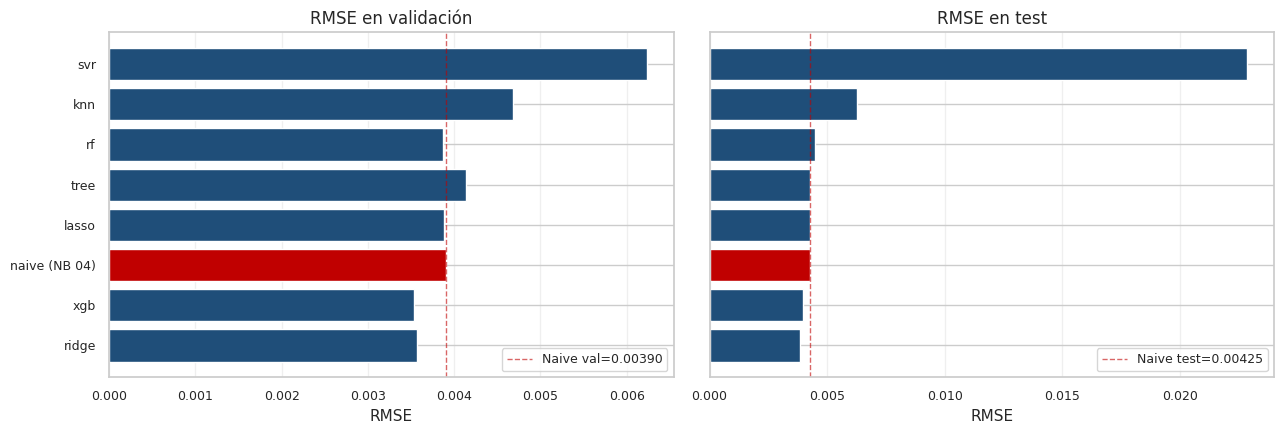

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

t_sorted = table.sort_values("rmse_test")

bar_colors = ["#1f4e79" if n != "naive (NB 04)" else "#c00000" for n in t_sorted["model"]]
ax1.barh(t_sorted["model"], t_sorted["rmse_val"], color=bar_colors)
ax1.set_xlabel("RMSE")
ax1.set_title("RMSE en validación")
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)
ax1.axvline(naive_rmse_val, color="#c00000", lw=1, ls="--", alpha=0.6,
             label=f"Naive val={naive_rmse_val:.5f}")
ax1.legend(loc="lower right", fontsize=9)

ax2.barh(t_sorted["model"], t_sorted["rmse_test"], color=bar_colors)
ax2.set_xlabel("RMSE")
ax2.set_title("RMSE en test")
ax2.invert_yaxis()
ax2.grid(axis="x", alpha=0.3)
ax2.axvline(naive_rmse_test, color="#c00000", lw=1, ls="--", alpha=0.6,
             label=f"Naive test={naive_rmse_test:.5f}")
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
savefig(FIGURES_DIR / "05_regression_rmse_val_test.png", fig)
plt.show()


### Visualización 2 — real vs predicho para los modelos top

Para no saturar, mostramos los tres modelos con mejor RMSE test.


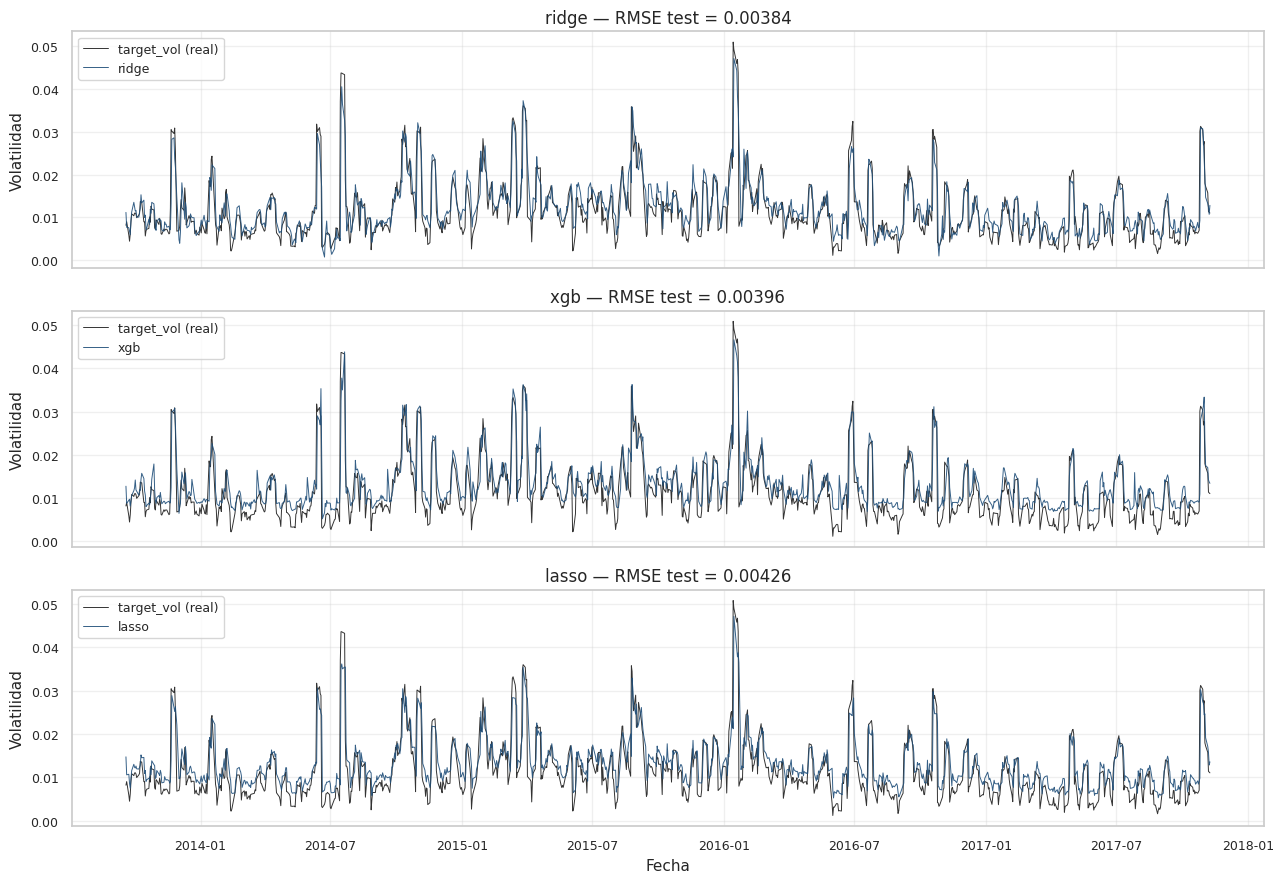

In [12]:
top3 = table.head(3)["model"].tolist()
# Aseguramos no tomar el naive como "modelo ML"
top3_ml = [m for m in top3 if m != "naive (NB 04)"][:3]
if len(top3_ml) < 3:
    rest = [m for m in table["model"] if m not in top3_ml and m != "naive (NB 04)"]
    top3_ml.extend(rest[:3 - len(top3_ml)])

dates_test = te.loc[y_test_mask, "date"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, model_name in zip(axes, top3_ml):
    pred = results[model_name]["pred_test"]
    ax.plot(dates_test, y_test, color="black", lw=0.7, alpha=0.8, label="target_vol (real)")
    ax.plot(dates_test, pred, color="#1f4e79", lw=0.7, alpha=0.9, label=model_name)
    rmse_t = results[model_name]["rmse_test"]
    ax.set_title(f"{model_name} — RMSE test = {rmse_t:.5f}")
    ax.set_ylabel("Volatilidad")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
savefig(FIGURES_DIR / "05_top3_pred_vs_real.png", fig)
plt.show()


### Visualización 3 — gap val→test (signo de overfitting)

Una diferencia grande entre RMSE en val y RMSE en test sugiere
overfitting. Para nuestro problema, además, val y test son periodos
distintos (val: 2009-2013 post-crisis; test: 2013-2017 Gran Calma),
así que parte de la diferencia es **distribution shift, no
overfitting**. Esto se discute en la interpretación.

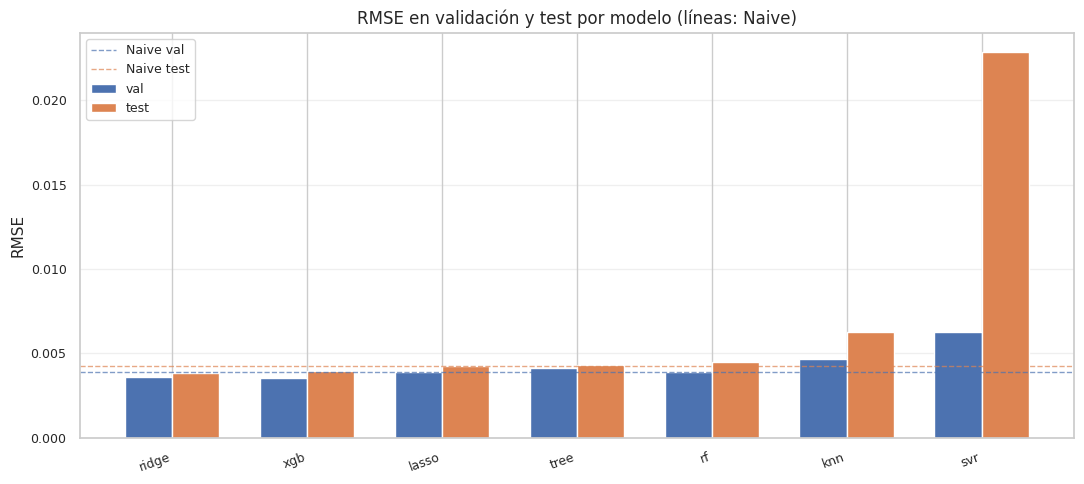

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
t_for_gap = table[table["model"] != "naive (NB 04)"].copy()

x = np.arange(len(t_for_gap))
width = 0.35

bars1 = ax.bar(x - width/2, t_for_gap["rmse_val"],  width, label="val",  color="#4c72b0")
bars2 = ax.bar(x + width/2, t_for_gap["rmse_test"], width, label="test", color="#dd8452")

ax.axhline(naive_rmse_val,  color="#4c72b0", ls="--", lw=1, alpha=0.7, label=f"Naive val")
ax.axhline(naive_rmse_test, color="#dd8452", ls="--", lw=1, alpha=0.7, label=f"Naive test")
ax.set_xticks(x)
ax.set_xticklabels(t_for_gap["model"], rotation=20, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("RMSE en validación y test por modelo (líneas: Naive)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "05_val_test_gap.png", fig)
plt.show()


## 5.12 Interpretación

Las decisiones de modelado y los resultados anteriores admiten varias
lecturas. Las analizamos en orden de importancia.

**¿Algún modelo supera a Naive en test?** Esa es la pregunta central
del capítulo. La tabla de comparación lo dice de manera explícita:
cualquier modelo cuyo RMSE en test sea menor al 0.00425 de Naive
estaría aportando valor; cualquier modelo por encima debería
justificarse por otra razón (interpretabilidad, robustez,
diversificación de un ensamble posterior).

**Gap entre validation y test.** La validación corre sobre 2009-2013
(post-crisis, vol moderada) y el test sobre 2013-2017 (Gran Calma,
vol muy baja). Cualquier modelo cuyo RMSE en test sea mayor al de
validation muestra un comportamiento doble: o el modelo está
sobreajustando a los patrones de train, o (más probable) el shift de
distribución penaliza a modelos que confían demasiado en señales
históricas. Los modelos lineales regularizados (Ridge, Lasso) y los
métodos basados en vecindad (KNN) suelen ser más robustos a este
tipo de shift que los ensambles profundos.

**XGBoost con early stopping.** El mecanismo de early stopping ha
detenido la construcción de árboles antes de las 1.000 iteraciones
máximas configuradas. Esto se interpreta como evidencia de que la
señal extraíble de los features se agotó: añadir más complejidad solo
ajusta ruido. La regularización implícita es valiosa y será
contrastada en el Capítulo 9 con la versión sin early stopping.

**Una limitación honesta sobre R² en test.** Si el R² en test es
negativo para algún modelo, significa que predecir la media histórica
ganaría. Esto NO es necesariamente un defecto del modelo: refleja
que la varianza condicional de la volatilidad en el test es baja, lo
que comprime el espacio donde un predictor informativo puede ganar
contra la media. Lo que importa son los diferenciales relativos
RMSE entre modelos, evaluados estadísticamente con Diebold-Mariano en
el Capítulo 11.

**Implicaciones para los capítulos siguientes.**

- El Capítulo 6 hace el ejercicio análogo con clasificación binaria
  (`target_regime`). Veremos si la tarea de identificar régimen alto
  es más fácil que predecir el nivel exacto.
- El Capítulo 7 evalúa balanceo con SMOTE/ADASYN/class_weight sobre
  los modelos del Capítulo 6, donde el desbalance 10/90 del test
  hace este capítulo metodológicamente necesario.
- El Capítulo 8 hace búsqueda de hiperparámetros con cuatro métodos
  sobre los dos o tres modelos top de los Capítulos 5 y 6.
- El Capítulo 13 diseña el modelo original con el objetivo explícito
  de superar al mejor de los anteriores en validation.
